# Неделя 4. Вторник
## Обучение без учителя
### Кластеризация текстов

In [49]:
import numpy as np
import pandas as pd
import re
import string
from collections import defaultdict
from sklearn import metrics
from time import time

import nltk

nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

nltk.download("wordnet")
import sklearn

sklearn.set_config(transform_output="pandas")

[nltk_data] Downloading package stopwords to /home/dmitry/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/dmitry/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [50]:
categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

dataset = fetch_20newsgroups(
    remove=("headers", "footers", "quotes"),
    subset="all",
    categories=categories,
    shuffle=True,
    random_state=42,
)

labels = dataset.target
unique_labels, category_sizes = np.unique(labels, return_counts=True)
true_k = unique_labels.shape[0]

# print(f"{len(dataset.data)} documents - {true_k} categories")

In [51]:
dataset.data[1]

"\nBy '8 grey level images' you mean 8 items of 1bit images?\nIt does work(!), but it doesn't work if you have more than 1bit\nin your screen and if the screen intensity is non-linear.\n\nWith 2 bit per pixel; there could be 1*c_1 + 4*c_2 timing,\nthis gives 16 levels, but they are linear if screen intensity is\nlinear.\nWith 1*c_1 + 2*c_2 it works, but we have to find the best\ncompinations -- there's 10 levels, but 16 choises; best 10 must be\nchosen. Different compinations for the same level, varies a bit, but\nthe levels keeps their order.\n\nReaders should verify what I wrote... :-)"

In [52]:
len(dataset.data)

3387

In [53]:
evaluations = []
evaluations_std = []


### функция проверки


def fit_and_evaluate(km, X, name=None, n_runs=5):
    name = km.__class__.__name__ if name is None else name

    train_times = []
    scores = defaultdict(list)
    for seed in range(n_runs):
        km.set_params(random_state=seed)
        t0 = time()
        km.fit(X)
        train_times.append(time() - t0)
        scores["Homogeneity"].append(metrics.homogeneity_score(labels, km.labels_))
        scores["Completeness"].append(metrics.completeness_score(labels, km.labels_))
        scores["V-measure"].append(metrics.v_measure_score(labels, km.labels_))
        scores["Adjusted Rand-Index"].append(
            metrics.adjusted_rand_score(labels, km.labels_)
        )
        scores["Silhouette Coefficient"].append(
            metrics.silhouette_score(X, km.labels_, sample_size=2000)
        )
    train_times = np.asarray(train_times)

    print(f"clustering done in {train_times.mean():.2f} ± {train_times.std():.2f} s ")
    evaluation = {
        "estimator": name,
        "train_time": train_times.mean(),
    }
    evaluation_std = {
        "estimator": name,
        "train_time": train_times.std(),
    }
    for score_name, score_values in scores.items():
        mean_score, std_score = np.mean(score_values), np.std(score_values)
        print(f"{score_name}: {mean_score:.3f} ± {std_score:.3f}")
        evaluation[score_name] = mean_score
        evaluation_std[score_name] = std_score
    evaluations.append(evaluation)
    evaluations_std.append(evaluation_std)

### 1. Предварительная очистка данных

In [54]:
# Функция очистки текста


def clean(text):
    text = text.lower()  # нижний регистр
    text = re.sub(r"http\S+", " ", text)  # удаляем ссылки
    text = re.sub(r"@\w+", " ", text)  # удаляем упоминания пользователей
    text = re.sub(r"#\w+", " ", text)  # удаляем хэштеги
    text = re.sub(r"\d+", " ", text)  # удаляем числа
    text = text.translate(str.maketrans("", "", string.punctuation))
    # text = re.sub(r'<.*?>',' ', text) #
    return text


cleaned_text = []

for text in dataset.data:
    cleaned_text.append(clean(text))

In [55]:
cleaned_text[1]

'\nby   grey level images you mean   items of  bit images\nit does work but it doesnt work if you have more than  bit\nin your screen and if the screen intensity is nonlinear\n\nwith   bit per pixel there could be  c    c  timing\nthis gives   levels but they are linear if screen intensity is\nlinear\nwith  c    c  it works but we have to find the best\ncompinations  theres   levels but   choises best   must be\nchosen different compinations for the same level varies a bit but\nthe levels keeps their order\n\nreaders should verify what i wrote '

### 2. Лемматизация

In [56]:
# create lemmatizer object
wn_lemmatizer = WordNetLemmatizer()

# Пример
wn_lemmatizer.lemmatize(
    "oranges", pos="n"
)  # pos = 'n'(noun) - лемматизация именно существительных, можно включить другие части речи

'orange'

In [57]:
lemmatized_text = []
for tweet in cleaned_text:
    lemmatized_text.append(
        " ".join([wn_lemmatizer.lemmatize(word) for word in tweet.split()])
    )

In [58]:
lemmatized_text

['my point is that you set up your view a the only way to believe saying that all eveil in this world is caused by atheism is ridiculous and counterproductive to dialogue in this newsgroups i see in your post a spirit of condemnation of the atheist in this newsgroup bacause they don t believe exactly a you do if youre here to try to convert the atheist here youre failing miserably who want to be in position of constantly defending themselves agaist insulting attack like you seem to like to do im sorry youre so blind that you didnt get the messgae in the quote everyone else ha seemed to',
 'by grey level image you mean item of bit image it doe work but it doesnt work if you have more than bit in your screen and if the screen intensity is nonlinear with bit per pixel there could be c c timing this give level but they are linear if screen intensity is linear with c c it work but we have to find the best compinations there level but choises best must be chosen different compinations for th

### 3. Токенизация

In [59]:
# Create and apply tokenizer

reg_tokenizer = RegexpTokenizer("\w+")

tokenized_text = reg_tokenizer.tokenize_sents(lemmatized_text)
tokenized_text

[['my',
  'point',
  'is',
  'that',
  'you',
  'set',
  'up',
  'your',
  'view',
  'a',
  'the',
  'only',
  'way',
  'to',
  'believe',
  'saying',
  'that',
  'all',
  'eveil',
  'in',
  'this',
  'world',
  'is',
  'caused',
  'by',
  'atheism',
  'is',
  'ridiculous',
  'and',
  'counterproductive',
  'to',
  'dialogue',
  'in',
  'this',
  'newsgroups',
  'i',
  'see',
  'in',
  'your',
  'post',
  'a',
  'spirit',
  'of',
  'condemnation',
  'of',
  'the',
  'atheist',
  'in',
  'this',
  'newsgroup',
  'bacause',
  'they',
  'don',
  't',
  'believe',
  'exactly',
  'a',
  'you',
  'do',
  'if',
  'youre',
  'here',
  'to',
  'try',
  'to',
  'convert',
  'the',
  'atheist',
  'here',
  'youre',
  'failing',
  'miserably',
  'who',
  'want',
  'to',
  'be',
  'in',
  'position',
  'of',
  'constantly',
  'defending',
  'themselves',
  'agaist',
  'insulting',
  'attack',
  'like',
  'you',
  'seem',
  'to',
  'like',
  'to',
  'do',
  'im',
  'sorry',
  'youre',
  'so',
  'bli

### 4. Удаление стоп-слов

In [60]:
# стоп-слова надо кэшировать
sw = stopwords.words("english")

clean_tokenized_text = []
for i, element in enumerate(tokenized_text):
    clean_tokenized_text.append(" ".join([word for word in element if word not in sw]))

In [61]:
sw = stopwords.words("english")

sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

### 5. Векторизация текста (text to matrix)

In [62]:
clean_tokenized_text

['point set view way believe saying eveil world caused atheism ridiculous counterproductive dialogue newsgroups see post spirit condemnation atheist newsgroup bacause believe exactly youre try convert atheist youre failing miserably want position constantly defending agaist insulting attack like seem like im sorry youre blind didnt get messgae quote everyone else ha seemed',
 'grey level image mean item bit image doe work doesnt work bit screen screen intensity nonlinear bit per pixel could c c timing give level linear screen intensity linear c c work find best compinations level choises best must chosen different compinations level varies bit level keep order reader verify wrote',
 'first annual phigs user group conference first annual phigs user group conference wa held march orlando florida conference wa organized rensse laer design research center cooperation ieee sig graph attendee came five country spanning three con tinents good crosssection phigs community wa represented confer

In [63]:
len(clean_tokenized_text)

3387

In [64]:
vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
t0 = time()
X_tfidf = vectorizer.fit_transform(clean_tokenized_text)

print(f"vectorization done in {time() - t0:.3f} s")
print(f"n_samples: {X_tfidf.shape[0]}, n_features: {X_tfidf.shape[1]}")

vectorization done in 0.231 s
n_samples: 3387, n_features: 6637


* 6637 токенов в нашем словаре

In [65]:
X_tfidf = pd.DataFrame(
    data=X_tfidf.toarray(), columns=vectorizer.get_feature_names_out()
)

X_tfidf

,aa,ab,abandon,abandoned,abbreviation,abc,ability,able,aboard,abomination,...,zbuffer,zealand,zero,zeus,zillion,zip,zone,zoom,zooming,zyxel
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.069584,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3383,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3385,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [66]:
kmeans = KMeans(
    n_clusters=true_k,
)

fit_and_evaluate(kmeans, X_tfidf, name="KMeans\non tf-idf vectors")

clustering done in 1.07 ± 0.24 s 
Homogeneity: 0.251 ± 0.017
Completeness: 0.294 ± 0.031
V-measure: 0.270 ± 0.022
Adjusted Rand-Index: 0.159 ± 0.015
Silhouette Coefficient: 0.008 ± 0.002


### 6. Понижение размерности

In [67]:
svd = make_pipeline(TruncatedSVD(n_components=100), Normalizer(copy=False))
# lsa = TruncatedSVD(n_components=100)
t0 = time()
X_svd = svd.fit_transform(X_tfidf)
explained_variance = svd[0].explained_variance_ratio_.sum()

print(f"SVD done in {time() - t0:.3f} s")
print(f"Explained variance of the SVD: {explained_variance * 100:.1f}%")

SVD done in 2.922 s
Explained variance of the SVD: 20.5%


In [68]:
X_svd.shape

(3387, 100)

In [69]:
kmeans = KMeans(
    n_clusters=true_k,
)

fit_and_evaluate(kmeans, X_svd, name="KMeans\nwith LSA on tf-idf vectors")

clustering done in 0.04 ± 0.02 s 
Homogeneity: 0.320 ± 0.068
Completeness: 0.354 ± 0.060
V-measure: 0.336 ± 0.064
Adjusted Rand-Index: 0.275 ± 0.081
Silhouette Coefficient: 0.029 ± 0.002


In [70]:
original_space_centroids = svd[0].inverse_transform(kmeans.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(true_k):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()

Cluster 0: file image thanks graphic program format know email help looking 
Cluster 1: dont space think people like ha time im know thing 
Cluster 2: wa think people year like know time space ha said 
Cluster 3: god jesus christian bible believe belief wa say people religion 


In [71]:
original_space_centroids

array([[ 1.17422742e-04,  1.25191654e-03, -5.48309875e-05, ...,
         1.24855603e-03,  2.46034450e-04,  9.75739961e-04],
       [ 2.91561832e-03,  6.49443673e-04,  1.01147006e-03, ...,
         3.16531625e-05,  2.37661044e-05,  1.43914410e-04],
       [ 3.71026774e-03,  3.96131990e-05,  7.14742167e-04, ...,
        -8.10363052e-05,  3.65732825e-04,  3.93396503e-05],
       [ 4.35963610e-03,  6.88986541e-05,  1.03651174e-03, ...,
         1.39695790e-05, -3.69046412e-05, -8.26881173e-05]],
      shape=(4, 6637))

### 7. Соединение в пайплайн Векторизации и понижения размерности

In [72]:
from sklearn.feature_extraction.text import HashingVectorizer, CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

svd_vectorizer = make_pipeline(
    HashingVectorizer(stop_words="english", n_features=50_000),
    TfidfTransformer(),  # Нужен для нормировки результатов с HashingVectorizer
    TruncatedSVD(n_components=100, random_state=0),
    Normalizer(copy=False),
)

t0 = time()
X_hashed_lsa = svd_vectorizer.fit_transform(dataset.data)
print(f"vectorization done in {time() - t0:.3f} s")

vectorization done in 3.149 s


In [73]:
fit_and_evaluate(kmeans, X_hashed_lsa, name="KMeans\nwith LSA on hashed vectors")

clustering done in 0.03 ± 0.02 s 
Homogeneity: 0.399 ± 0.007
Completeness: 0.447 ± 0.014
V-measure: 0.421 ± 0.010
Adjusted Rand-Index: 0.344 ± 0.027
Silhouette Coefficient: 0.030 ± 0.002


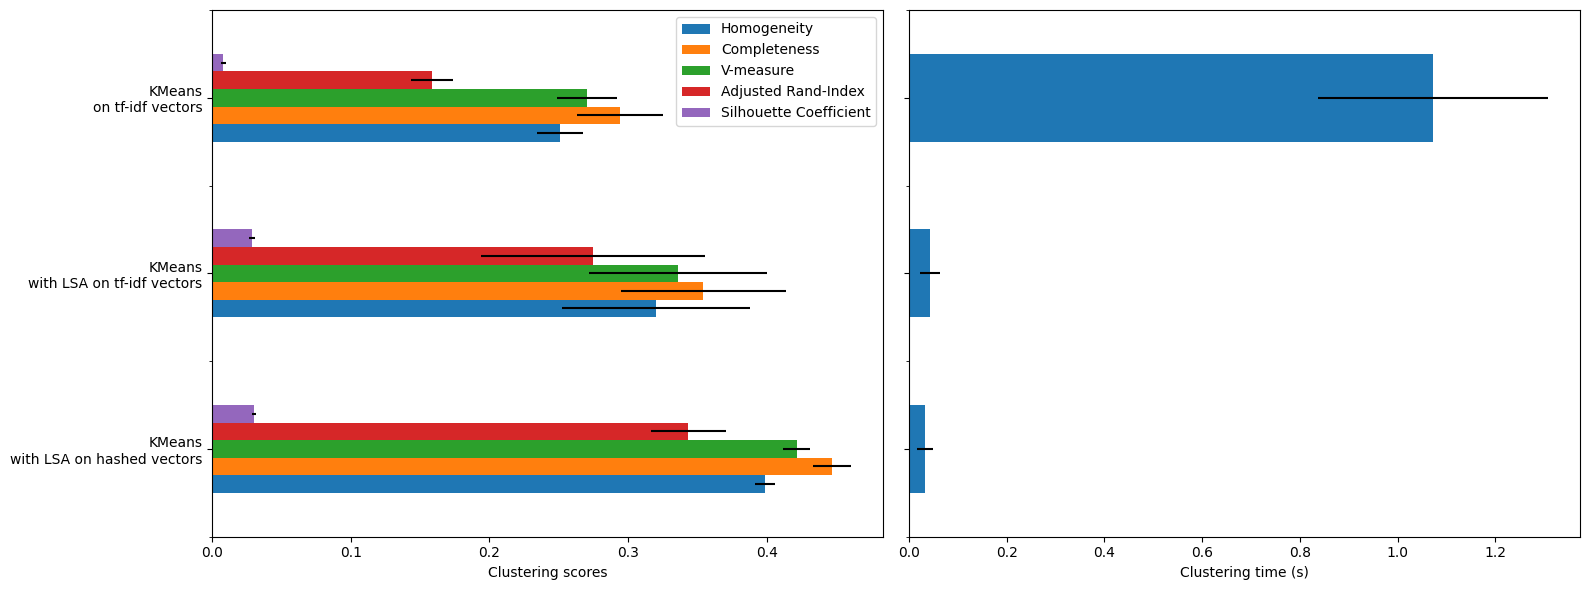

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(ncols=2, figsize=(16, 6), sharey=True)

df = pd.DataFrame(evaluations[::-1]).set_index("estimator")
df_std = pd.DataFrame(evaluations_std[::-1]).set_index("estimator")

df.drop(
    ["train_time"],
    axis="columns",
).plot.barh(ax=ax0, xerr=df_std)
ax0.set_xlabel("Clustering scores")
ax0.set_ylabel("")

df["train_time"].plot.barh(ax=ax1, xerr=df_std["train_time"])
ax1.set_xlabel("Clustering time (s)")
plt.tight_layout()